# Chapter 167 — Scaling via Matrices

> **Prerequisites:** Matrix visualization *(ch165)*, linear transformations *(ch164)*
> **You will learn:**
> - Diagonal matrices as scaling transformations
> - Non-uniform scaling and its effect on shapes
> - Scaling in arbitrary directions (via eigenvectors)
> - How scaling relates to covariance and whitening
>
> **Environment:** Python 3.x, numpy, matplotlib

C:\Users\user\AppData\Local\Temp\ipykernel_1312\107915914.py:12: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  circle = np.row_stack([np.cos(t), np.sin(t)])


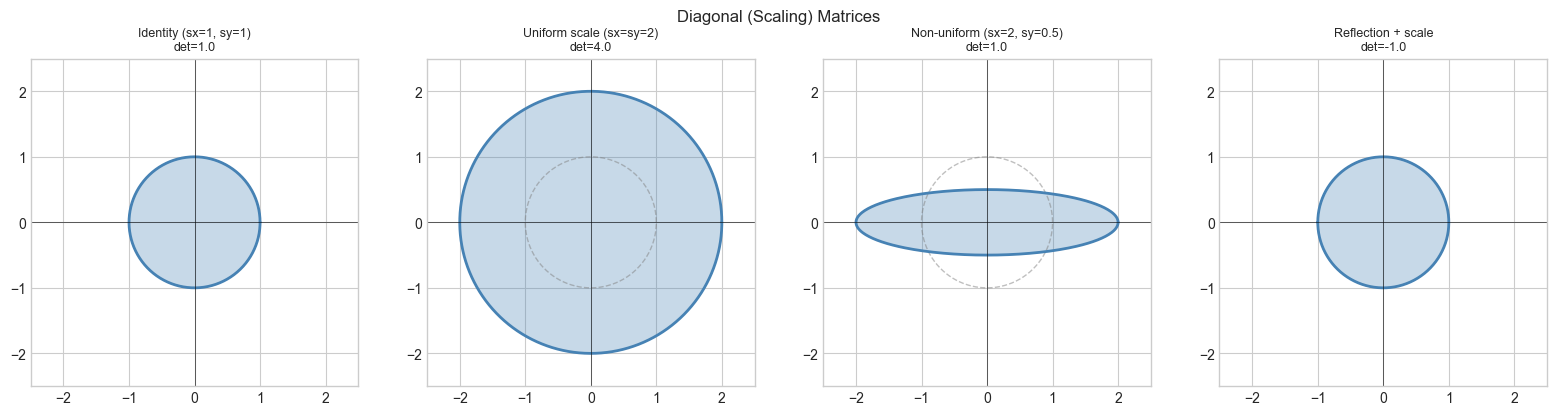

Arbitrary-direction scale matrix:
[[2. 1.]
 [1. 2.]]
Scale in direction v=[0.70710678 0.70710678]: 3.0000  (expected 3.0)
Scale in direction perp: 1.0000  (expected 1)


In [1]:
# --- Scaling via Matrices ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def scale2d(sx, sy):
    """Scale x by sx, y by sy."""
    return np.array([[sx,0],[0,sy]])

# Uniform and non-uniform scaling
t = np.linspace(0, 2*np.pi, 300)
circle = np.row_stack([np.cos(t), np.sin(t)])

fig, axes = plt.subplots(1, 4, figsize=(16,4))
configs = [
    (scale2d(1,1),   'Identity (sx=1, sy=1)'),
    (scale2d(2,2),   'Uniform scale (sx=sy=2)'),
    (scale2d(2,0.5), 'Non-uniform (sx=2, sy=0.5)'),
    (scale2d(-1,1),  'Reflection + scale'),
]
for ax, (S, title) in zip(axes, configs):
    result = S @ circle
    ax.plot(circle[0], circle[1], 'gray', lw=1, linestyle='--', alpha=0.5, label='Original')
    ax.fill(result[0], result[1], alpha=0.3, color='steelblue')
    ax.plot(result[0], result[1], 'steelblue', lw=2)
    ax.set_title(f'{title}\ndet={np.linalg.det(S):.1f}', fontsize=9)
    ax.set_xlim(-2.5,2.5); ax.set_ylim(-2.5,2.5); ax.set_aspect('equal')
    ax.axhline(0,color='k',lw=0.4); ax.axvline(0,color='k',lw=0.4)

plt.suptitle('Diagonal (Scaling) Matrices', fontsize=12)
plt.tight_layout(); plt.show()

# Scaling in arbitrary direction (not axis-aligned)
# Stretch by 3 in direction [1,1]/sqrt(2)
v = np.array([1,1]) / np.sqrt(2)  # unit direction
stretch = 3.0
# Outer product construction: scale by (stretch-1) in direction v
S_arb = np.eye(2) + (stretch - 1) * np.outer(v, v)
print(f"Arbitrary-direction scale matrix:\n{np.round(S_arb,4)}")
print(f"Scale in direction v={v}: {np.linalg.norm(S_arb @ v):.4f}  (expected {stretch})")
print(f"Scale in direction perp: {np.linalg.norm(S_arb @ np.array([-v[1],v[0]])):.4f}  (expected 1)")

---

## 4. Mathematical Formulation

```
Diagonal scaling matrix D = diag(d₁, d₂, ..., dₙ):
  D[i,j] = dᵢ if i==j, else 0
  (Dv)[i] = dᵢ * v[i]    — scale each coordinate independently

Properties:
  det(D) = ∏ dᵢ           — product of diagonal entries
  D⁻¹ = diag(1/d₁,...,1/dₙ)  (requires all dᵢ ≠ 0)
  D is symmetric           — scaling commutes

Scaling in arbitrary direction u (unit vector), scale factor s:
  S = I + (s-1) * uuᵀ     — adds (s-1) times the projection onto u
  Eigenvalues: s (in direction u), 1 (perpendicular)
```

---

## 7. Exercises

**Easy 1.** What is the inverse of `diag(2, 3, 5)`? Verify numerically.

**Easy 2.** Write `scale3d(sx, sy, sz)` and apply it to a cube. Plot before and after.

**Medium 1.** Implement `whitening(X)` that scales data X so that each feature has unit variance. This is `diag(std)⁻¹ @ X`. Verify the output has std=1 per feature.

**Medium 2.** Show that any symmetric positive definite matrix A can be written as `Q D Qᵀ` where D is diagonal (all eigenvalues) and Q is orthogonal. This is the eigendecomposition — scale in eigen-directions.

**Hard.** Implement anisotropic Gaussian sampling using a scaling matrix: given a covariance matrix Σ, generate samples from N(0, Σ) using `L @ z` where `z ~ N(0,I)` and L is the Cholesky factor of Σ.

---

## 9. Chapter Summary & Connections

- Diagonal matrices scale each axis independently. `det(D) = ∏ dᵢ`.
- Scaling in an arbitrary direction u: `S = I + (s-1)uuᵀ`.
- The eigendecomposition `A = QDQᵀ` reveals the natural scaling axes of a symmetric matrix.

**Forward connections:**
- In ch172 (Diagonalization), every diagonalizable matrix is a rotation-scale-rotation composition `A = PDP⁻¹`.
- In ch173 (SVD), the singular values in Σ are the scaling factors of the transformation.